In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, _), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = np.reshape(x_train, (-1, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
latent_dim = 100

def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_dim=latent_dim),
        layers.Dense(256, activation="relu"),
        layers.Dense(28*28, activation="sigmoid"),
        layers.Reshape((28, 28, 1))
    ])
    return model

generator = build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

discriminator = build_discriminator()
discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(latent_dim,))
generated_img = generator(gan_input)
gan_output = discriminator(generated_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer="adam", loss="binary_crossentropy")

In [6]:
batch_size = 128
epochs = 10000

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0, D Loss: 0.6887078285217285, G Loss: 0.5308524370193481
Epoch 1000, D Loss: 5.350691795349121, G Loss: 0.0018867283361032605
Epoch 2000, D Loss: 5.632931232452393, G Loss: 0.0009505718480795622
Epoch 3000, D Loss: 5.75883674621582, G Loss: 0.0006375107332132757
Epoch 4000, D Loss: 5.828542709350586, G Loss: 0.0004807926598004997
Epoch 5000, D Loss: 5.872440338134766, G Loss: 0.0003867102204822004
Epoch 6000, D Loss: 5.902875900268555, G Loss: 0.00032395636662840843
Epoch 7000, D Loss: 5.9256391525268555, G Loss: 0.00027910800417885184
Epoch 8000, D Loss: 5.943268299102783, G Loss: 0.00024546051281504333
Epoch 9000, D Loss: 5.957417964935303, G Loss: 0.00021928023488726467


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


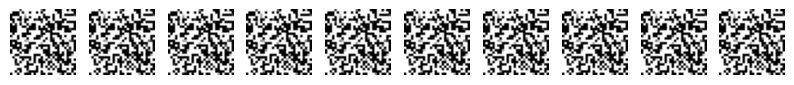

In [8]:
noise = np.random.normal(0, 1, (10, latent_dim))
generated_images = generator.predict(noise)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
plt.show()